In [1]:
import pandas as pd
import numpy as np
import os, datetime
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [9, 6]

# interactive plot
%matplotlib widget

In [2]:
folder_name = 'C:/Users/azhang/Desktop/WPy64-31180/notebooks/_decsvisa/src/output/'
# file_name = '20260630_100207_mc_stability.csv'
# test_date = '26-06-30'

file_name = '20260702_154620_mc_temp_sequence.csv'
test_date = '26-07-02'

df = pd.read_csv(folder_name + file_name, header=0, delimiter=',')

df['Time (minute)'] = (df['elapsed_s'] - df['elapsed_s'].iloc[0])/60

# df['Timestamp (hour)'] = (df['Time'] - df['Time'].iloc[0]) / (1000 * 60 * 60)
print(df.info())
# print(df.head(5))
# df.to_csv(folder_name + test_date + '_cooling_power.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              553 non-null    object 
 1   elapsed_s              553 non-null    float64
 2   step_index             553 non-null    int64  
 3   step_elapsed_s         553 non-null    float64
 4   target_mc_setpoint_k   553 non-null    float64
 5   target_mc_setpoint_mk  553 non-null    float64
 6   mc_temp_k              553 non-null    float64
 7   mc_temp_mk             553 non-null    float64
 8   mc_setpoint_k          553 non-null    float64
 9   mc_setpoint_mk         553 non-null    float64
 10  mc_heater_power_w      553 non-null    float64
 11  mc_heater_power_uw     553 non-null    float64
 12  still_temp_k           553 non-null    float64
 13  still_temp_mk          553 non-null    float64
 14  still_heater_power_w   553 non-null    float64
 15  still_

for idx, col in enumerate(df.columns) :
    print(f"{idx}: {col}")

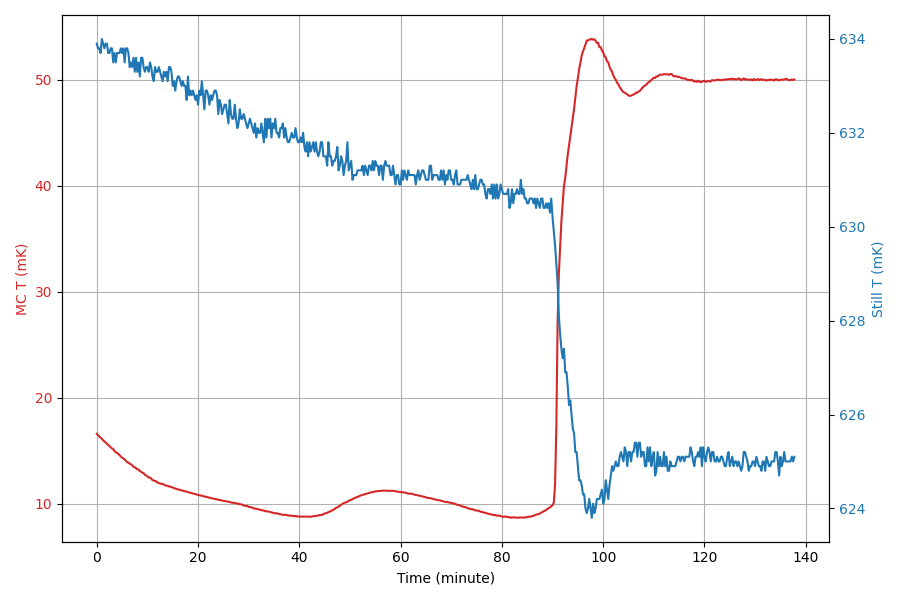

In [3]:
# xcolumn_index = 13
# ycolumn_index = 6
# ycolumn2_index = 8
# ycolumn3_index = 10

xcolumn_index = 16
ycolumn_index = 7
ycolumn2_index = 13

x_axis = df[df.columns[xcolumn_index]]
y_axis = df[df.columns[ycolumn_index]]
y_axis2 = df[df.columns[ycolumn2_index]]

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(df.columns[xcolumn_index])
ax1.set_ylabel('MC T (mK)', color=color)
ax1.plot(x_axis, y_axis, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Still T (mK)', color=color)  # we already handled the x-label with ax1
ax2.plot(x_axis, y_axis2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

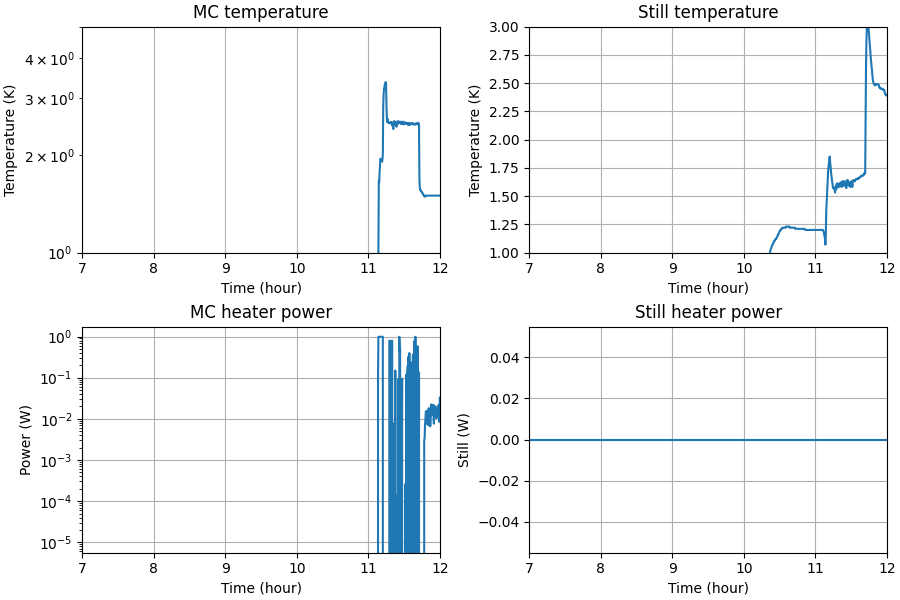

In [4]:
# Make a plot with 4 different system parameters, (a) outlet pressure (b) sample heater current (c) turbo pump current (d) chamber pressure

# interactive plot
# %matplotlib widget
y2column_index = 107
y2column2_index = 85
y2column3_index = 111
y2column4_index = 113

x2_axis = df[df.columns[xcolumn_index]]
y2_axis = df[df.columns[y2column_index]]
y2_axis2 = df[df.columns[y2column2_index]]
y2_axis3 = df[df.columns[y2column3_index]]
y2_axis4 = df[df.columns[y2column4_index]]

# fig2 = plt.figure(figsize=(9,6), layout='constrained')
fig2 = plt.figure(layout='constrained')
axs = fig2.subplot_mosaic([['2a', '2b'],
                          ['2c', '2d']])

# axs['2a'].set_title('Outlet Pressure')
# axs['2a'].plot(x2_axis, y2_axis)
# axs['2a'].set_xlabel(df.columns[xcolumn_index)
# axs['2a'].set_ylabel(df.columns[y2column_index)

low_x = 7
high_x = 12

axs['2a'].set_xlim(low_x, high_x)
axs['2b'].set_xlim(low_x, high_x)
axs['2c'].set_xlim(low_x, high_x)
axs['2d'].set_xlim(low_x, high_x)

axs['2a'].plot(x2_axis, y2_axis)
axs['2a'].set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (K)', title='MC temperature', yscale='log')
# axs['2a'].set(xlabel=df.columns[xcolumn_index], ylabel=df.columns[y2column_index], title='Outlet Pressure')
axs['2a'].set_ylim(6e-3, 30e-3)
axs['2a'].grid()

axs['2b'].plot(x2_axis, y2_axis2)
axs['2b'].set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (K)', title='Still temperature')
axs['2b'].set_ylim(0.59, 0.65)
axs['2b'].grid()

axs['2c'].plot(x2_axis, y2_axis3)
axs['2c'].set(xlabel=df.columns[xcolumn_index], ylabel='Power (W)', title='MC heater power', yscale='log')
axs['2c'].set_ylim(0.1e-6, 10e-6)
axs['2c'].grid()

axs['2d'].plot(x2_axis, y2_axis4)
axs['2d'].set(xlabel=df.columns[xcolumn_index], ylabel='Still (W)', title='Still heater power')
axs['2d'].set_ylim(0, 1e-3)
axs['2d'].grid()

# fig2.savefig(folder_name + test_date + test_type + " Figure 2.png")
plt.show()

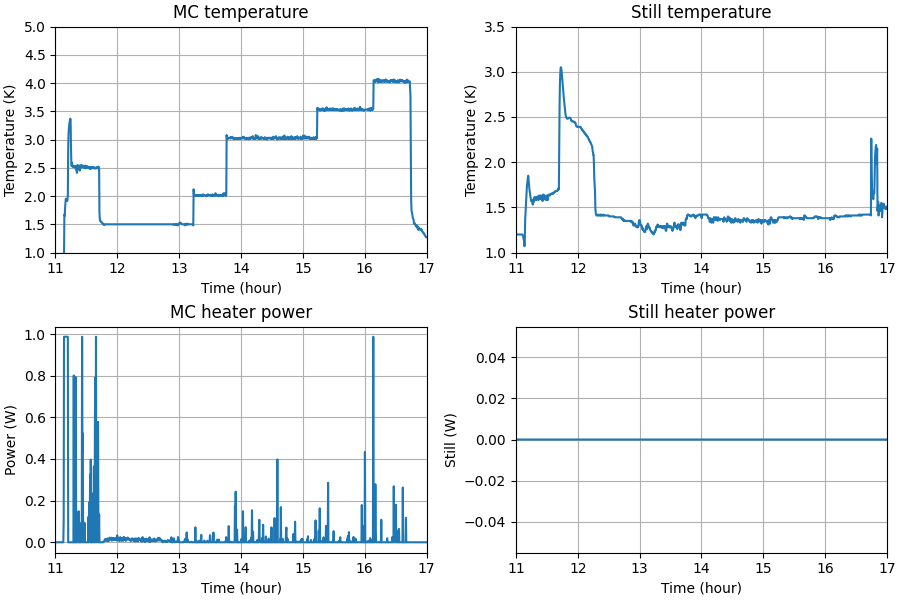

In [7]:
# Make a plot with 4 different system parameters, (a) outlet pressure (b) sample heater current (c) turbo pump current (d) chamber pressure
x3_axis = df[df.columns[xcolumn_index]]
y3_axis = df[df.columns[y2column_index]]
y3_axis2 = df[df.columns[y2column2_index]]
y3_axis3 = df[df.columns[y2column3_index]]
y3_axis4 = df[df.columns[y2column4_index]]

fig3 = plt.figure(layout='constrained')
axs = fig3.subplot_mosaic([['3a', '3b'],
                          ['3c', '3d']])

# axs['2a'].set_title('Outlet Pressure')
# axs['2a'].plot(x2_axis, y2_axis)
# axs['2a'].set_xlabel(df.columns[xcolumn_index)
# axs['2a'].set_ylabel(df.columns[y2column_index)
low_x2 = 11
high_x2 = 17

axs['3a'].plot(x3_axis, y3_axis)
# axs['3a'].set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (K)', title='MC temperature', yscale='log')
axs['3a'].set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (K)', title='MC temperature')
axs['3a'].set_ylim(1000e-3, 5000e-3)
axs['3a'].grid()

axs['3b'].plot(x3_axis, y3_axis2)
axs['3b'].set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (K)', title='Still temperature')
axs['3b'].set_ylim(1, 3.5)
axs['3b'].grid()

axs['3c'].plot(x3_axis, y3_axis3)
axs['3c'].set(xlabel=df.columns[xcolumn_index], ylabel='Power (W)', title='MC heater power')
# axs['3c'].set_ylim(1000e-6, 10000e-6)

axs['3c'].grid()
axs['3d'].plot(x3_axis, y3_axis4)
axs['3d'].set(xlabel=df.columns[xcolumn_index], ylabel='Still (W)', title='Still heater power')
# axs['3d'].set_ylim(1000e-6, 3000e-6)
axs['3d'].grid()

axs['3a'].set_xlim(low_x2, high_x2)
axs['3b'].set_xlim(low_x2, high_x2)
axs['3c'].set_xlim(low_x2, high_x2)
axs['3d'].set_xlim(low_x2, high_x2)

# fig3.savefig(folder_name + test_date + test_type + " Figure 3.png")
plt.show()

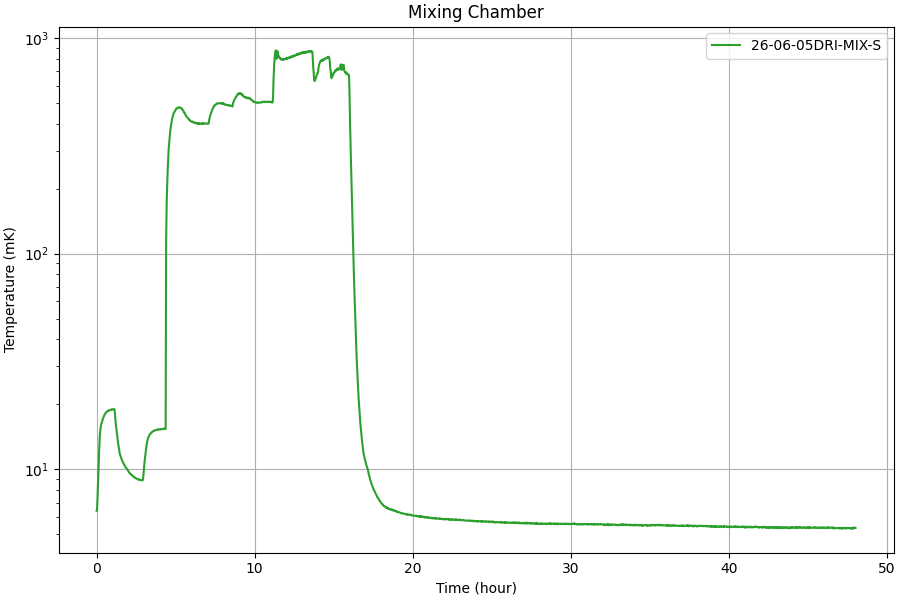

In [4]:
# Make plot by selecting the columns

# plot for temperatures
# Time  PTR1-PT1-S  PTR1-PT2-S  DRI-PT2-S  DRI-PT1-S  Timestamp

x2column_index = 13
# y2column_index = 8
# y2column2_index = 9
y2column3_index = 10

x2_axis = df[df.columns[x2column_index]]
# y2_axis = df[df.columns[y2column_index]]
# y2_axis2 = df[df.columns[y2column2_index]]
y2_axis3 = df[df.columns[y2column3_index]]
# y2_axis4 = df11[df11.columns[y2column_index]]
# y2_axis5 = df11[df11.columns[y2column2_index]]
# y2_axis6 = df11[df11.columns[y2column3_index]]

fig2, ax = plt.subplots(layout='constrained')
# ax.plot(x_axis, y_axis, x_axis, y_axis2, x_axis, y_axis3, x_axis, y_axis4, x_axis, y_axis5, x_axis, y_axis6)

# Run 1
# ax.plot(x2_axis, y2_axis, color='C0', label=test_date + df.columns[y2column_index])
# ax.plot(x2_axis, y2_axis2, color='C1',label=test_date + df.columns[y2column2_index])
ax.plot(x2_axis, y2_axis3, color='C2', label=test_date + df.columns[y2column3_index])

# Run 2
# ax.plot(x2_axis, y2_axis4, color='C0', linestyle='--', label=test2_date + df11.columns[y2column_index])
# ax.plot(x2_axis, y2_axis5, color='C1', linestyle='--', label=test2_date + df11.columns[y2column2_index])
# ax.plot(x2_axis, y2_axis6, color='C2', linestyle='--', label=test2_date + df11.columns[y2column3_index])

# low_x = -5
# high_x = 710

# ax.set_xlim(low_x, high_x)
# ax.set_ylim(0.3, 400)
plt.yscale('log')

ax.set(xlabel=df.columns[xcolumn_index], ylabel='Temperature (mK)', title='Mixing Chamber')
ax.legend()
# ax.legend((test_date + df.columns[ycolumn_index], test_date + df.columns[ycolumn2_index], test_date + df.columns[ycolumn3_index],
           # test2_date + df11.columns[ycolumn_index], test2_date + df11.columns[ycolumn2_index], test_date + df11.columns[ycolumn3_index]), loc='best', ncols=1)
ax.grid()

# fig.savefig(folder_name + test_date + test_type + " Figure 1.png")
plt.show()

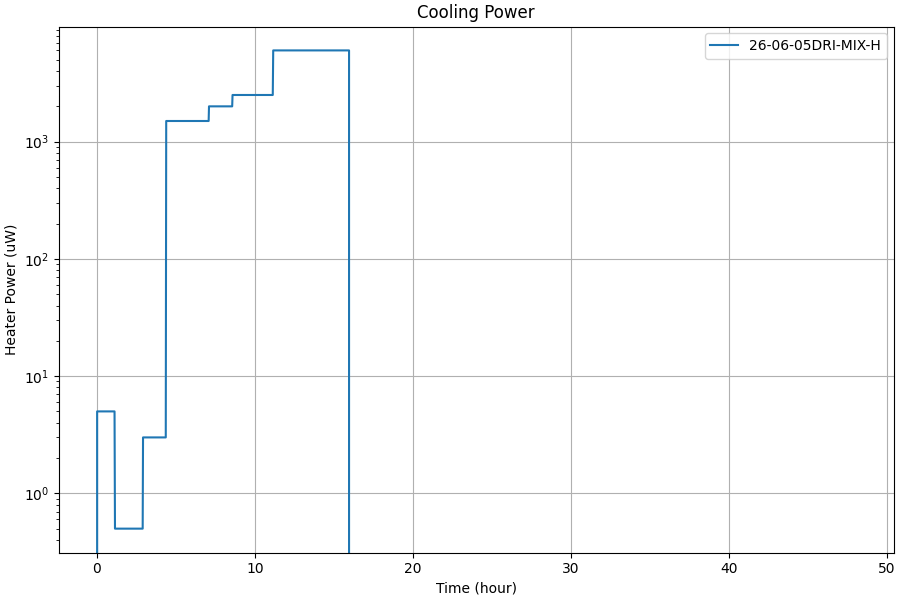

In [5]:
# Make plot by selecting the columns

# plot for temperatures
# Time  PTR1-PT1-S  PTR1-PT2-S  DRI-PT2-S  DRI-PT1-S  Timestamp

x3column_index = 13
y3column_index = 11
# y2column2_index = 9
# y2column3_index = 10

x3_axis = df[df.columns[x3column_index]]
y3_axis = df[df.columns[y3column_index]]
# y2_axis2 = df[df.columns[y2column2_index]]
# y2_axis3 = df[df.columns[y2column3_index]]
# y3_axis4 = df11[df11.columns[y3column_index]]
# y2_axis5 = df11[df11.columns[y2column2_index]]
# y2_axis6 = df11[df11.columns[y2column3_index]]

fig3, ax = plt.subplots(layout='constrained')
# ax.plot(x_axis, y_axis, x_axis, y_axis2, x_axis, y_axis3, x_axis, y_axis4, x_axis, y_axis5, x_axis, y_axis6)

# Run 1
ax.plot(x3_axis, y3_axis, color='C0', label=test_date + df.columns[y3column_index])
# ax.plot(x2_axis, y2_axis2, color='C1',label=test_date + df.columns[y2column2_index])
# ax.plot(x2_axis, y2_axis3, color='C2', label=test_date + df.columns[y2column3_index])

# Run 2
# ax.plot(x3_axis, y3_axis4, color='C0', linestyle='--', label=test2_date + df11.columns[y3column_index])
# ax.plot(x2_axis, y2_axis5, color='C1', linestyle='--', label=test2_date + df11.columns[y2column2_index])
# ax.plot(x2_axis, y2_axis6, color='C2', linestyle='--', label=test2_date + df11.columns[y2column3_index])

# low_x = -5
# high_x = 710

# ax.set_xlim(low_x, high_x)
# ax.set_ylim(0.3, 400)
# plt.xscale('log')
plt.yscale('log')

ax.set(xlabel=df.columns[xcolumn_index], ylabel='Heater Power (uW)', title='Cooling Power')
ax.legend()
# ax.legend((test_date + df.columns[ycolumn_index], test_date + df.columns[ycolumn2_index], test_date + df.columns[ycolumn3_index],
           # test2_date + df11.columns[ycolumn_index], test2_date + df11.columns[ycolumn2_index], test_date + df11.columns[ycolumn3_index]), loc='best', ncols=1)
ax.grid()

# fig.savefig(folder_name + test_date + test_type + " Figure 1.png")
plt.show()